# ISyE 6525 HW2 — Question 4
## Edge detection and segmentation


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import convolve
from sklearn.cluster import KMeans

RGB shape: (512, 768, 3); grayscale shape: (512, 768)


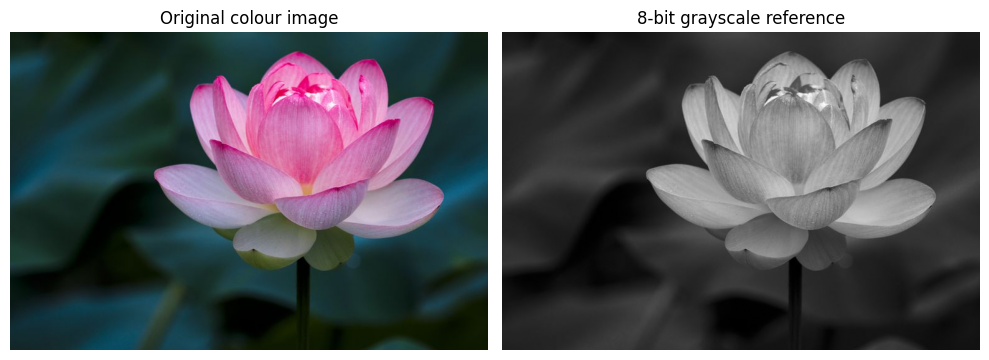

In [2]:
IMAGE_PATH = Path("Flower.jpg")
if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Expected {IMAGE_PATH.resolve()}")
with Image.open(IMAGE_PATH) as source:
    flower_rgb = np.asarray(source.convert("RGB"), dtype=np.uint8)
    flower_gray = np.asarray(source.convert("L"), dtype=np.uint8)
gray_float = flower_gray.astype(np.float64)
print(f"RGB shape: {flower_rgb.shape}; grayscale shape: {flower_gray.shape}")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(flower_rgb)
axes[0].set_title("Original colour image")
axes[1].imshow(flower_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("8-bit grayscale reference")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## (a) Laplacian of Gaussian (8 pts)

For

$$
G(x,y)=\frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right),
$$

compute $\nabla^2G=\frac{\partial^2G}{\partial x^2}+\frac{\partial^2G}{\partial y^2}$ and show the derivation.

### Derivation
For fixed $\sigma>0$, write $G=G(x,y)$. The first derivative is

$$
\frac{\partial G}{\partial x}
=\frac{1}{2\pi\sigma^2}\left(-\frac{2x}{2\sigma^2}\right)\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
=-\frac{x}{\sigma^2}G.
$$

Second partial derivative with respect to $x$:
$$
\begin{aligned}
\frac{\partial^2G}{\partial x^2}
&=-\frac{1}{\sigma^2}G-\frac{x}{\sigma^2}\frac{\partial G}{\partial x}\\
&=-\frac{1}{\sigma^2}G+\frac{x^2}{\sigma^4}G\\
&=\frac{x^2-\sigma^2}{\sigma^4}G.
\end{aligned}
$$

By symmetry,

$$
\frac{\partial^2G}{\partial y^2}=\frac{y^2-\sigma^2}{\sigma^4}G.
$$

Adding the two second partial derivatives gives

$$
\boxed{\nabla^2G(x,y)=\frac{x^2+y^2-2\sigma^2}{\sigma^4}G(x,y)
=\frac{x^2+y^2-2\sigma^2}{2\pi\sigma^6}\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right).}
$$

### Construct and apply the Laplacian-of-Gaussian kernel

- Construct a $5\times5$ LoG kernel with $\sigma=1$ on $x,y\in\{-2,-1,0,1,2\}$.
- Report the kernel numerically.
- Explain why the sampled kernel should be shifted so its entries sum to zero.
- Convolve it with the grayscale image and display the result.

Raw 5×5 LoG kernel (sigma=1):
[[ 0.01749   0.039193  0.043079  0.039193  0.01749 ]
 [ 0.039193  0.       -0.096532  0.        0.039193]
 [ 0.043079 -0.096532 -0.31831  -0.096532  0.043079]
 [ 0.039193  0.       -0.096532  0.        0.039193]
 [ 0.01749   0.039193  0.043079  0.039193  0.01749 ]]
Raw sampled sum: -0.14862288
Zero-sum 5×5 LoG kernel:
[[ 0.023435  0.045138  0.049023  0.045138  0.023435]
 [ 0.045138  0.005945 -0.090587  0.005945  0.045138]
 [ 0.049023 -0.090587 -0.312365 -0.090587  0.049023]
 [ 0.045138  0.005945 -0.090587  0.005945  0.045138]
 [ 0.023435  0.045138  0.049023  0.045138  0.023435]]
Shifted sampled sum: +7.633e-17


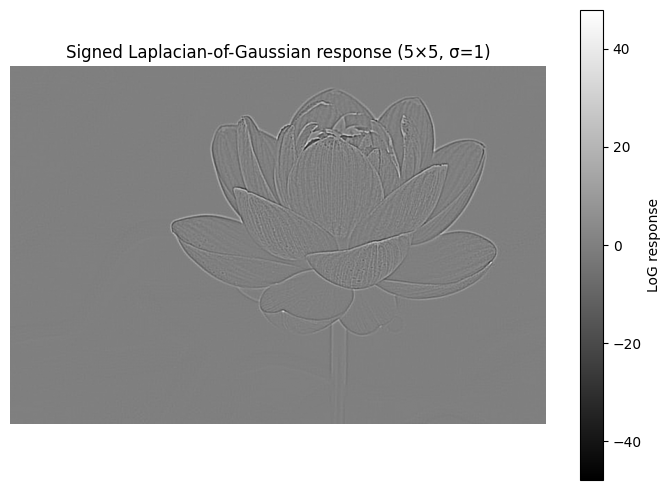

In [3]:
# Sample the derived Laplacian of Gaussian on integer grid
sigma = 1.0
yy, xx = np.mgrid[-2:3, -2:3]
laplacian_factor = (xx ** 2 + yy ** 2 - 2*sigma**2)/(sigma**4)
gaussian = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
log_kernel_raw = laplacian_factor * gaussian
print("Raw 5×5 LoG kernel (sigma=1):")
print(np.array2string(log_kernel_raw, precision=6, suppress_small=True))
print(f"Raw sampled sum: {log_kernel_raw.sum():+.8f}")

# Shift the kernel so its entries sum to zero
log_kernel = log_kernel_raw - log_kernel_raw.mean()
print("Zero-sum 5×5 LoG kernel:")
print(np.array2string(log_kernel, precision=6, suppress_small=True))
print(f"Shifted sampled sum: {log_kernel.sum():+.3e}")
np.testing.assert_allclose(log_kernel.sum(), 0.0, atol=1e-12)

# Convolve the image with the zero-sum LoG kernel to detect edges
flower_log = convolve(gray_float, log_kernel, mode="reflect")
scale = np.max(np.abs(flower_log))
plt.figure(figsize=(7, 5))
plt.imshow(flower_log, cmap="gray", vmin=-scale, vmax=scale)
plt.title("Signed Laplacian-of-Gaussian response (5×5, σ=1)")
plt.colorbar(label="LoG response")
plt.axis("off")
plt.tight_layout()
plt.show()

### Zero-sum explanation

The continuous Laplacian of Gaussian integrates to zero on the infinite plane because it is a second derivative of a rapidly decaying Gaussian. Sampling it on a finite 5×5 grid in practice produces a nonzero sum due to finite sampling, introducing a non-zero output in constant-intensity area. Subtracting the sampled kernel's mean enforces $\sum_{i,j}h_{ij}=0$, so its convolution with an exactly constant image is zero.

## (b) Sobel and Prewitt edge detection (7 pts)

For both the Sobel and Prewitt operators:

- Compute the first partial derivatives $f_x$ and $f_y$ of the grayscale image.
- Form $|\nabla f|=\sqrt{f_x^2+f_y^2}$.
- Display thresholded edge maps for at least four cutoff values.
- Describe what happens as the cutoff increases.
- State which operator gives the larger response and explain why.

In [4]:

edge_cutoffs = (40, 80, 120, 160)

def show_derivatives_and_edges(fx, fy, magnitude, operator, cutoffs):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    derivative_limit = max(float(np.abs(fx).max()), float(np.abs(fy).max()))
    for ax, values, title in zip(
        axes, (fx, fy, magnitude), ("$f_x$", "$f_y$", "$|\\nabla f|$")
    ):
        kwargs = (dict(vmin=-derivative_limit, vmax=derivative_limit)
                  if values is not magnitude else dict(vmin=0))
        ax.imshow(values, cmap="gray", **kwargs)
        ax.set_title(f"{operator}: {title}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    fig, axes = plt.subplots(1, len(cutoffs), figsize=(4 * len(cutoffs), 4))
    for ax, cutoff in zip(axes, cutoffs):
        binary_map = magnitude >= cutoff
        ax.imshow(binary_map, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{operator}: cutoff ≥ {cutoff}\\n{binary_map.mean():.1%} edge pixels")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


### Sobel operator

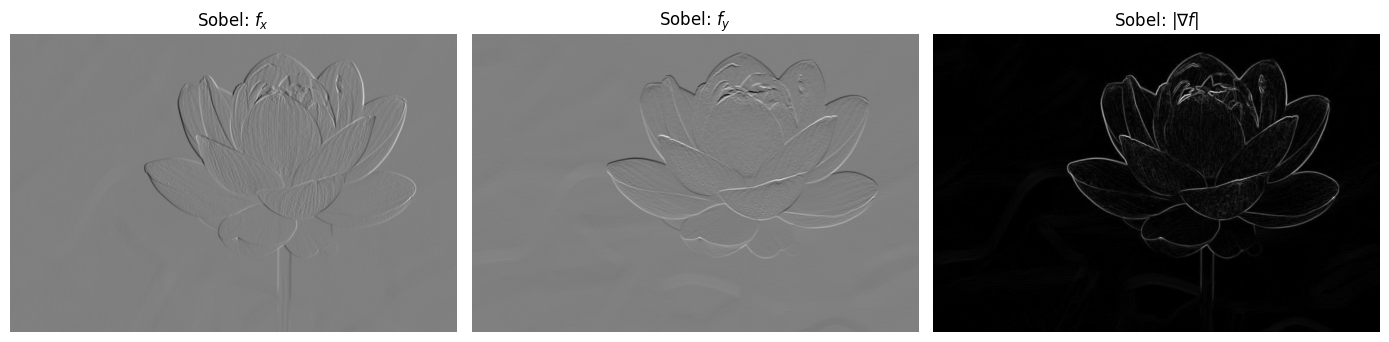

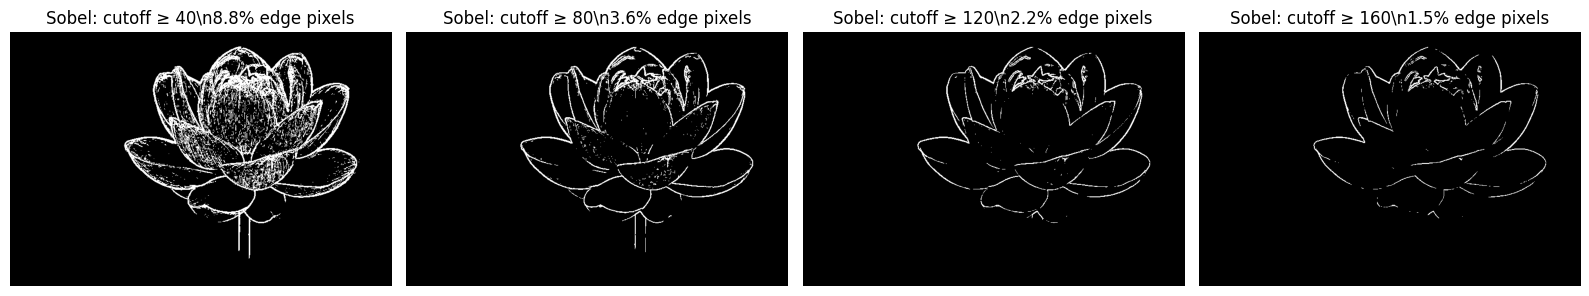

In [5]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
sobel_y = sobel_x.T
sobel_fx = convolve(gray_float, sobel_x, mode="reflect")
sobel_fy = convolve(gray_float, sobel_y, mode="reflect")
sobel_magnitude = np.hypot(sobel_fx, sobel_fy)

show_derivatives_and_edges(sobel_fx, sobel_fy, sobel_magnitude, "Sobel", edge_cutoffs)


### Prewitt operator

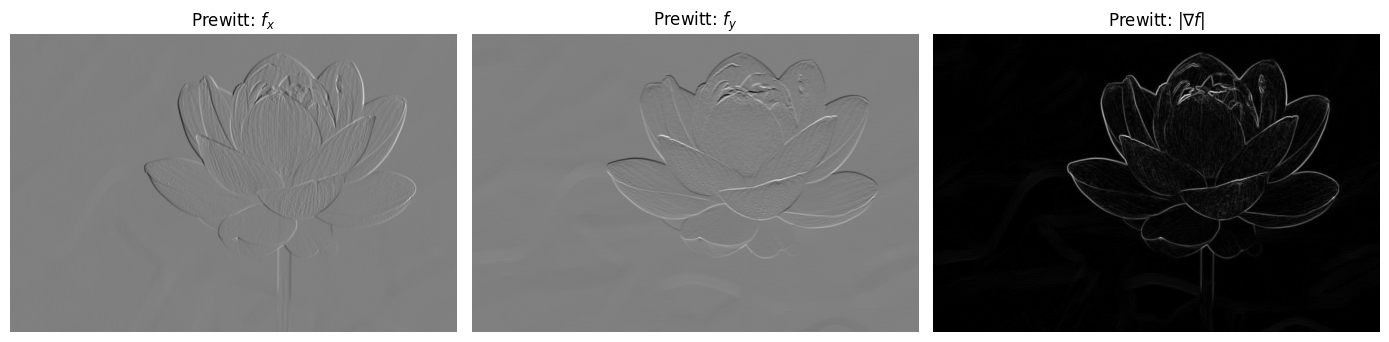

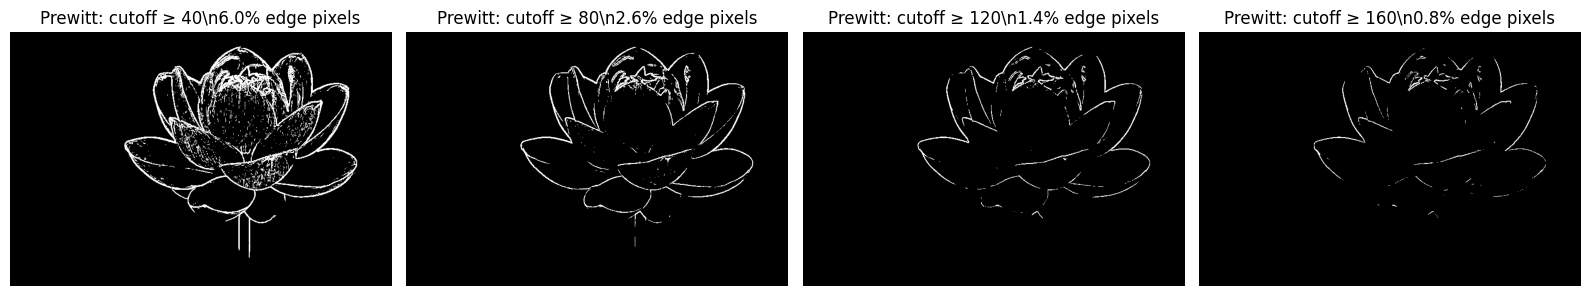

In [6]:
prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=float)
prewitt_y = prewitt_x.T
prewitt_fx = convolve(gray_float, prewitt_x, mode="reflect")
prewitt_fy = convolve(gray_float, prewitt_y, mode="reflect")
prewitt_magnitude = np.hypot(prewitt_fx, prewitt_fy)

show_derivatives_and_edges(prewitt_fx, prewitt_fy, prewitt_magnitude,
                           "Prewitt", edge_cutoffs)


In [7]:

print(f"Mean raw gradient: Sobel={sobel_magnitude.mean():.3f}, "
      f"Prewitt={prewitt_magnitude.mean():.3f}")
print(f"Maximum raw gradient: Sobel={sobel_magnitude.max():.3f}, "
      f"Prewitt={prewitt_magnitude.max():.3f}")
print(f"Fraction of pixels with stronger Sobel response: "
      f"{np.mean(sobel_magnitude > prewitt_magnitude):.2%}")

Mean raw gradient: Sobel=16.386, Prewitt=12.103
Maximum raw gradient: Sobel=650.538, Prewitt=457.089
Fraction of pixels with stronger Sobel response: 79.98%


### Edge-map comparison

As the cutoff increases, the edge maps become sparser, highlighting only the stronger edges.

Comparing the Sobel and Prewitt magnitude at each pixel, we can see that 80% of the pixels respond stronger to the Sobel operator.

The Sobel operator gives more weight to the central row/column (weight 2) compared to the Prewitt operator (weight 1), which generally results in a larger raw gradient magnitude for the Sobel operator on this image.

## (c) Colour segmentation with k-means (6 pts)

k=2 RGB cluster centres (rows = clusters; values in [0,255]):
[[ 22.39  47.08  44.71]
 [192.09 125.13 171.38]]
k=3 RGB cluster centres (rows = clusters; values in [0,255]):
[[ 27.96  59.4   61.47]
 [193.02 125.4  172.1 ]
 [ 14.59  28.57  19.43]]
k=4 RGB cluster centres (rows = clusters; values in [0,255]):
[[ 14.26  27.92  18.6 ]
 [156.85 102.49 140.44]
 [ 26.63  58.46  60.3 ]
 [208.96 136.59 186.23]]
k=5 RGB cluster centres (rows = clusters; values in [0,255]):
[[ 29.65  68.82  75.75]
 [160.36 102.67 142.6 ]
 [ 11.11  21.58  10.58]
 [209.35 137.65 187.05]
 [ 23.63  48.15  45.11]]


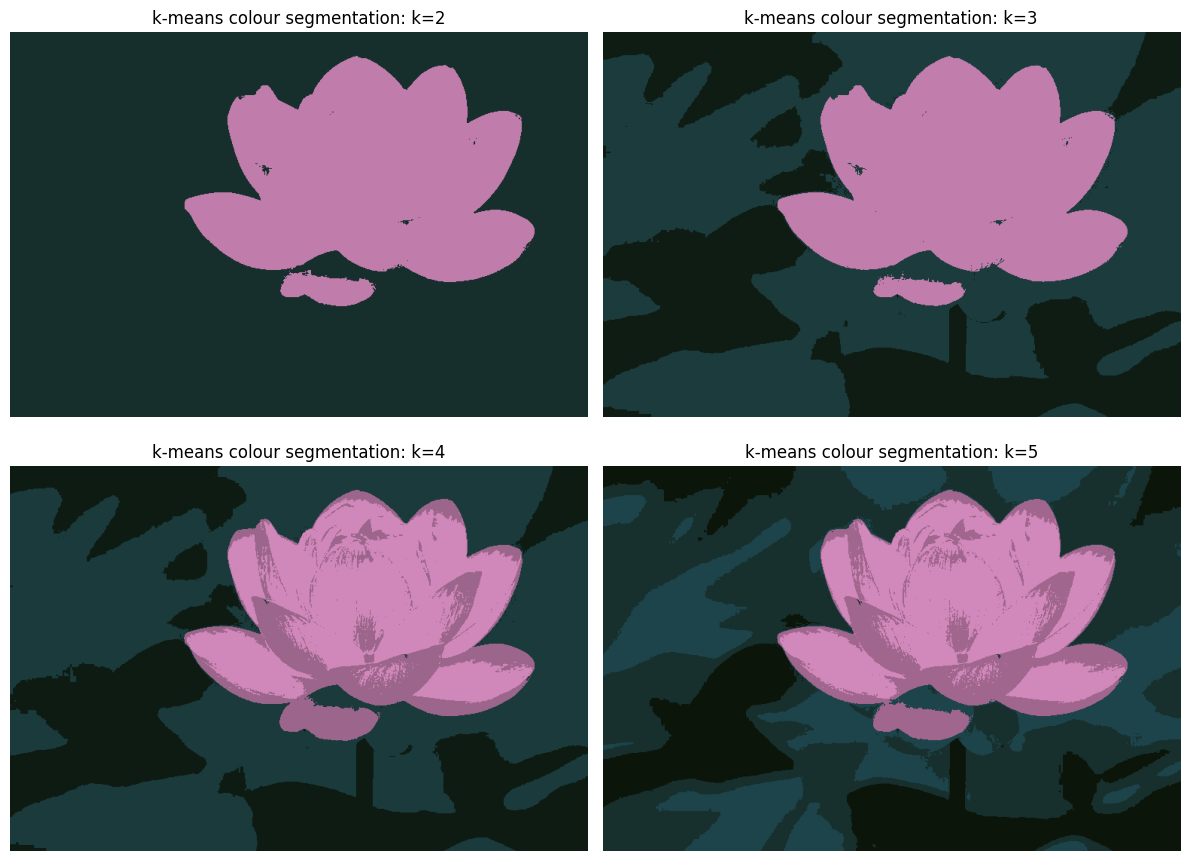

In [8]:
pixel_rgb = flower_rgb.reshape(-1, 3).astype(np.float64)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
kmeans_results = {}
for ax, k in zip(axes.flat, (2, 3, 4, 5)):
    model = KMeans(n_clusters=k, n_init=5, max_iter=300, random_state=6525)
    labels = model.fit_predict(pixel_rgb)
    centres = model.cluster_centers_
    segmented = np.clip(centres[labels], 0, 255).reshape(flower_rgb.shape).astype(np.uint8)
    kmeans_results[k] = {"centres": centres.copy(), "segmented": segmented}
    ax.imshow(segmented)
    ax.set_title(f"k-means colour segmentation: k={k}")
    ax.axis("off")
    print(f"k={k} RGB cluster centres (rows = clusters; values in [0,255]):")
    print(np.array2string(centres, precision=2, suppress_small=True))
plt.tight_layout()
plt.show()

## (d) Multilevel Otsu segmentation (4 pts)

DP formulation:

Let dp[k, end] be the optimal within-class variance using k-1 thresholds to split pixel intensities in the range [0, end) into k classes.
The objective is to minimize the within-class variance.

The recurrence relation is:

dp[k, end] = min_{start in [k-1, end)} ( dp[k-1, start] + (s_{start:end}^2 / n_{start:end}) )

where s_{start:end} is the sum of pixel intensities in the range [start, end) and n_{start:end} is the number of pixels in that range.

In [ ]:
def multilevel_otsu_thresholds(image, n_classes):
    """
        K-1 thresholds split the intensity range of the image into K contiguous classes, that minimize the within-class variance.
    """
    gray = np.asarray(image)
    histogram = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    prefix_count = np.concatenate(([0.0], np.cumsum(histogram)))
    prefix_sum = np.concatenate(([0.0], np.cumsum(histogram * np.arange(256))))

    dp = np.full((n_classes + 1, 257), -np.inf, dtype=float)
    previous = np.full((n_classes + 1, 257), -1, dtype=np.int32)
    dp[0, 0] = 0.0
    for k in range(1, n_classes + 1):
        for end in range(k, 257):
            start = np.arange(k - 1, end)
            count = prefix_count[end] - prefix_count[start]
            intensity_sum = prefix_sum[end] - prefix_sum[start]
            valid = (count > 0) & np.isfinite(dp[k - 1, start])
            candidate = np.full(start.shape, -np.inf, dtype=float)
            candidate[valid] = dp[k - 1, start][valid] + intensity_sum[valid] ** 2 / count[valid]
            best = int(np.argmax(candidate))
            if np.isfinite(candidate[best]):
                dp[k, end] = candidate[best]
                previous[k, end] = start[best]

    if not np.isfinite(dp[n_classes, 256]):
        raise ValueError("Unable to construct the requested nonempty classes")
    thresholds = []
    end = 256
    for k in range(n_classes, 1, -1):
        start = int(previous[k, end])
        thresholds.append(start - 1)
        end = start
    return np.asarray(thresholds[::-1], dtype=np.uint8)



2 levels: thresholds=[95]; class means=[39.4, 151.12]
3 levels: thresholds=[36, 100]; class means=[22.73, 49.93, 151.87]
4 levels: thresholds=[35, 88, 147]; class means=[21.94, 48.72, 127.4, 167.76]
5 levels: thresholds=[27, 48, 93, 148]; class means=[15.76, 39.04, 57.96, 129.1, 168.3]


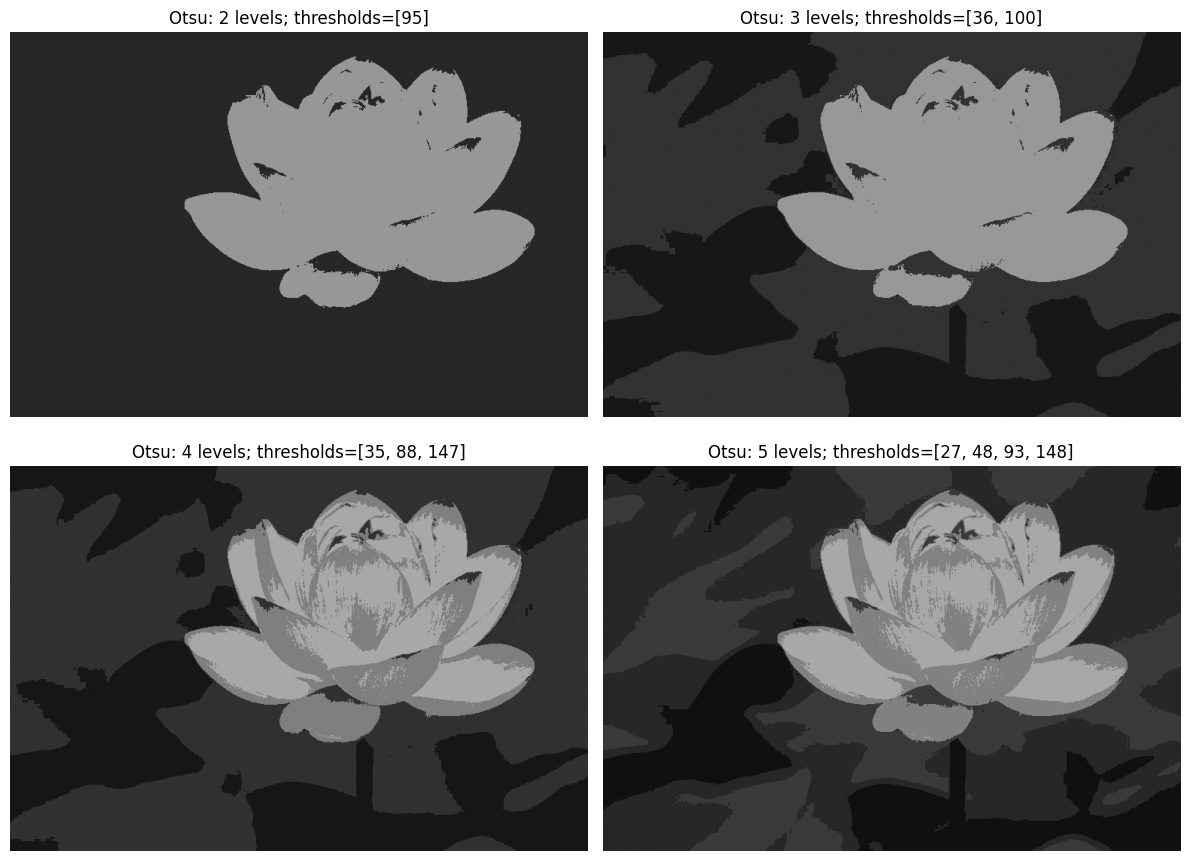

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
otsu_results = {}
for ax, n_classes in zip(axes.flat, (2, 3, 4, 5)):
    thresholds = multilevel_otsu_thresholds(flower_gray, n_classes)
    labels = np.searchsorted(thresholds, flower_gray, side="left")
    mean_intensities = np.array(
        [float(flower_gray[labels == label].mean()) for label in range(n_classes)]
    )
    quantized = np.rint(mean_intensities[labels]).astype(np.uint8)
    otsu_results[n_classes] = {
        "thresholds": thresholds, "means": mean_intensities, "image": quantized
    }
    ax.imshow(quantized, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Otsu: {n_classes} levels; thresholds={thresholds.tolist()}")
    ax.axis("off")
    print(f"{n_classes} levels: thresholds={thresholds.tolist()}; "
          f"class means={np.round(mean_intensities, 2).tolist()}")
plt.tight_layout()
plt.show()